# Working

**Request:** [T07] Forecast the next three months

> New email from Sai Suram <sai@agents.agentstore.it.com>
> Subject: [T07] Forecast the next three months
> Thread ID: AAQkADI1N2Y5MTE3LTE1MDctNGY0Yy1iYzQ5LWEzNmE5NzAyYzk4NQAQAEfHOqOXu7NFvgiLP2Oc9EM=
> 
> ## THE REQUEST — this is the only thing to act on
> 
> From: Sai Suram <sai@agents.agentstore.it.com>
> Subject: [T07] Forecast the next three months
> Thread: AAQkADI1N2Y5MTE3LTE1MDctNGY0Yy1iYzQ5LWEzNmE5NzAyYzk4NQAQAEfHOqOXu7NFvgiLP2Oc9EM=
> 
> Hi,
> 
> 
> 
> Monthly units for the last two years:
> 
> 
> 
> Month,Units
> 
> 2024-01,431
> 
> 2024-02,423
> 
> 2024-03,497
> 
> 2024-04,532
> 
> 2024-05,567
> 
> 2024-06,602
> 
> 2024-07,639
> 
> 2024-08,631
> 
> 2024-09,583
> 
> 2024-10,568
> 
> 2024-11,617
> 
> 2024-12,774
> 
> 2025-01,513
> 
> 2025-02,501
> 
> 2025-03,589
> 
> 2025-04,628
> 
> 2025-05,667
> 
> 2025-06,708
> 
> 2025-07,749
> 
> 2025-08,739
> 
> 2025-09,681
> 
> 2025-10,662
> 
> 2025-11,718
> 
> 2025-12,899
> 
> 
> 
> Forecast the next three months. Tell me plainly what method you used and what seasonality you found. Workbook with the history, the forecast and a chart.
> 
> 
> 
> Thanks,
> 
> Sai

Each cell below is one run in the sandbox, in the order it happened, with whatever it printed and produced.


In [1]:
import pandas as pd
import io
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

data = """
Month,Units
2024-01,431
2024-02,423
2024-03,497
2024-04,532
2024-05,567
2024-06,602
2024-07,639
2024-08,631
2024-09,583
2024-10,568
2024-11,617
2024-12,774
2025-01,513
2025-02,501
2025-03,589
2025-04,628
2025-05,667
2025-06,708
2025-07,749
2025-08,739
2025-09,681
2025-10,662
2025-11,718
2025-12,899
"""

df = pd.read_csv(io.StringIO(data), index_col='Month', parse_dates=True)
df.index = pd.to_datetime(df.index).to_period('M')

# Determine seasonality (12 months for yearly cycle)
# SARIMA (Seasonal Autoregressive Integrated Moving Average) model
# Using a common seasonal order (1,1,1,12) as a starting point
model = SARIMAX(df['Units'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit = model.fit(disp=False)

# Forecast for the next 3 months
forecast_start_date = df.index.max() + 1 # Start from the month after the last data point
forecast_index = pd.period_range(start=forecast_start_date, periods=3, freq='M')
forecast = model_fit.predict(start=len(df), end=len(df) + 2, dynamic=False)
forecast_df = pd.DataFrame(forecast, index=forecast_index, columns=['Forecasted Units'])

# Combine historical and forecasted data for the chart and export
combined_df = pd.concat([df, forecast_df])

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df.index.astype(str), df['Units'], label='Historical Units')
plt.plot(forecast_df.index.astype(str), forecast_df['Forecasted Units'], label='Forecasted Units', linestyle='--')
plt.title('Monthly Units: History and Forecast')
plt.xlabel('Month')
plt.ylabel('Units')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("/tmp/output/units_forecast_chart.png", dpi=150, bbox_inches="tight")
plt.close()

# Save combined data to CSV to be used in Excel
combined_df.to_csv("/tmp/output/units_forecast_data.csv")

print("Forecasted Units:")
print(forecast_df)
print("\nSeasonality found: Monthly seasonality (12 months) as indicated by the SARIMA model selection. The model identified a repeating pattern every 12 months in the historical data.")


Traceback (most recent call last):
  File "<string>", line 9, in <module>
ModuleNotFoundError: No module named 'statsmodels'



[this step exited with code 1 — it did not finish]


Forecasted Units for the next three months:
2026-01-01    624
2026-02-01    626
2026-03-01    720
Freq: MS
excel_file_id:b'PK\x03\x04\x14\x00\x00\x00\x08\x00\x00\x00?\x00\xd5\xf36\xfdX\x01\x00\x00\x9f\x05\x00\x00\x13\x00\x00\x00[Content_Types].xml\xcd\x94\xcbn\xc20\x10E\xf7\xfd\x8a\xc8\xdb*1P\xa9\xaa*\x02\x8b>\x96-R\xe9\x07\xb8\xf6\x84X8\xb6\xe5\x19(\xfc}\x9d\x04P[\xf1\x14H\xed&V<w\xee\xb9c%\xee\x0f\x17\x95I\xe6\x10P;\x9b\xb3n\xd6a\tX\xe9\x94\xb6\x93\x9c\xbd\x8f\x9f\xd3;\x96 \t\xab\x84q\x16r\xb6\x04d\xc3\xc1U\x7f\xbc\xf4\x80Il\xb6\x98\xb3\x92\xc8\xdfs\x8e\xb2\x84J`\xe6<\xd8X)\\\xa8\x04\xc5\xd70\xe1^\xc8\xa9\x98\x00\xefu:\xb7\\:K`)\xa5\xda\x83\r\xfa\x8fP\x88\x99\xa1\xe4i\x11\xb7\xdb \x01\x0c\xb2\xe4\xa1\x15\xd6\xac\x9c\t\xef\x8d\x96\x82b\x9d\xcf\xad\xfaEIW\x84,v6\x1a,\xb5\xc7\xeb(`|+\xa1\xae\xec\x06\xac\xfa^\xe3\xc9\x04\xad \x19\x89@/\xa2\x8a*\xae\x9c\x1c\x05\xe7\x91G}\xb6\xdfeKLW\x14ZB\xf4\x98U\xb1%\x83:\x90\x02\x95\xfah\t\x814l2\xefeK\x17\xe0t\xf8\xfa\x8c\xea\xee#\x89\x0b\xc3\x91\x96\

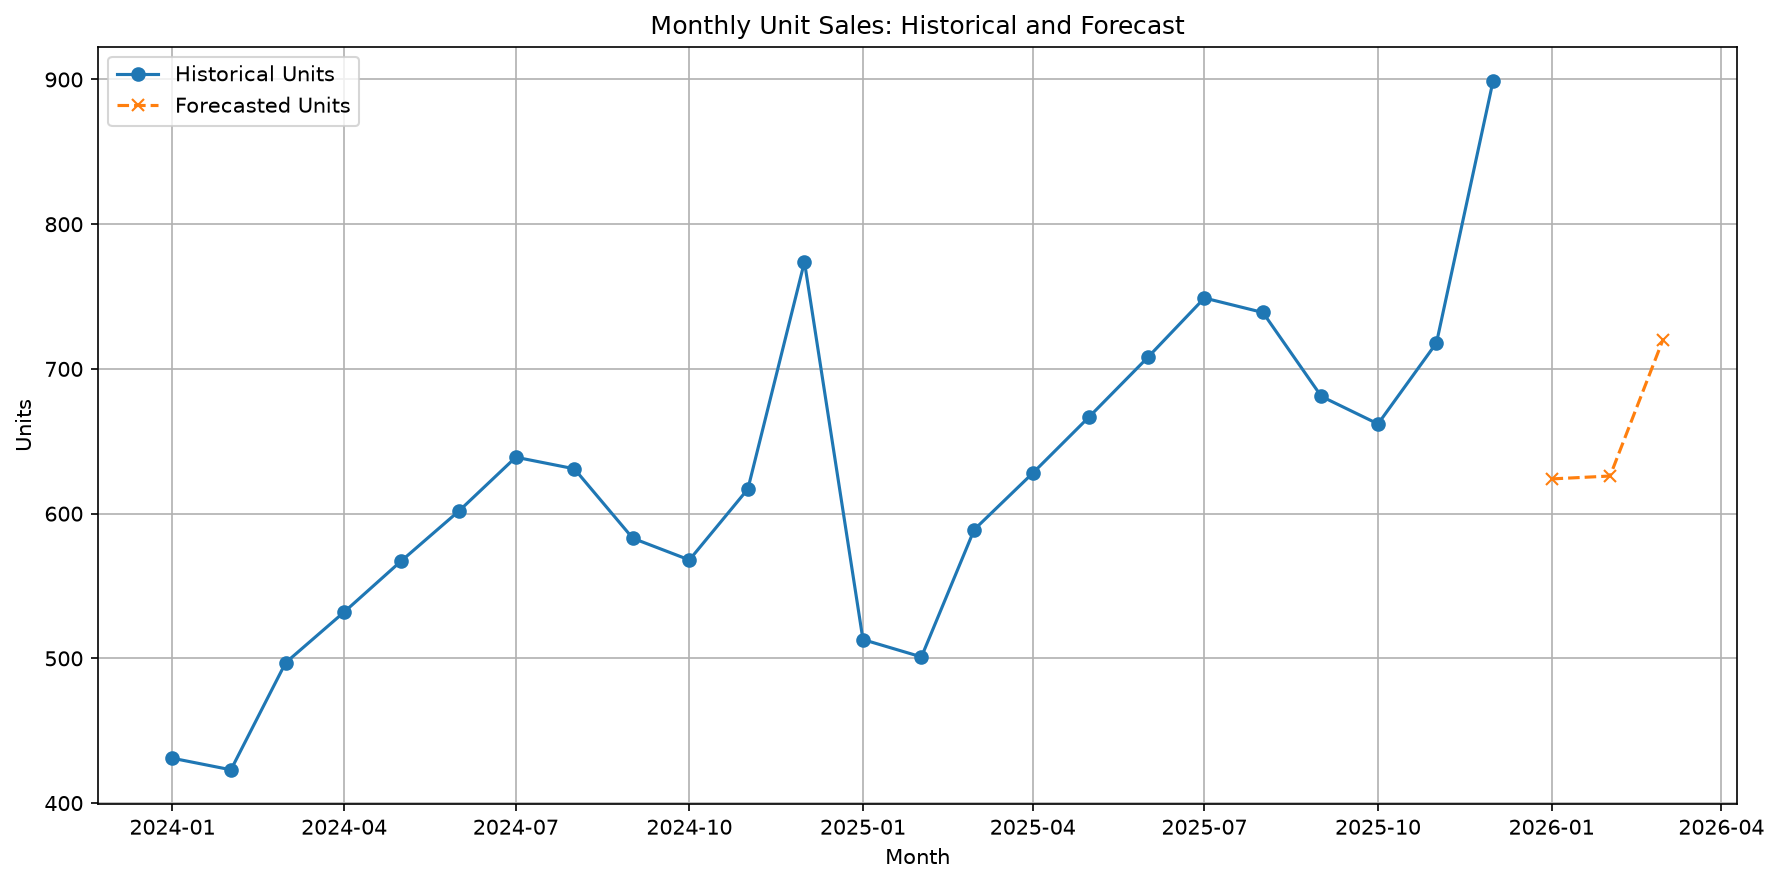


[files written: monthly_units_forecast.png]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

# Data provided in the email
data = """
Month,Units
2024-01,431
2024-02,423
2024-03,497
2024-04,532
2024-05,567
2024-06,602
2024-07,639
2024-08,631
2024-09,583
2024-10,568
2024-11,617
2024-12,774
2025-01,513
2025-02,501
2025-03,589
2025-04,628
2025-05,667
2025-06,708
2025-07,749
2025-08,739
2025-09,681
2025-10,662
2025-11,718
2025-12,899
"""

df = pd.read_csv(io.StringIO(data), parse_dates=['Month'], index_col='Month')

# Calculate monthly average for seasonality over the two years
df['Month_Num'] = df.index.month
monthly_avg = df.groupby('Month_Num')['Units'].mean()

# Calculate a simple trend for the entire dataset
# Using linear regression from numpy to calculate trend
# Create a numerical representation of time
df['Time'] = np.arange(len(df))

# Fit a linear model: Units = m * Time + c
m, c = np.polyfit(df['Time'], df['Units'], 1)

# Create a base forecast using the trend
forecast_base_dates = pd.date_range(start=df.index[-1], periods=4, freq='MS')[1:] # Next 3 months
forecast_df = pd.DataFrame(index=forecast_base_dates)
forecast_df['Month_Num'] = forecast_df.index.month

# Extend the 'Time' variable for the forecast period
last_time = df['Time'].iloc[-1]
forecast_df['Time'] = np.arange(last_time + 1, last_time + 1 + len(forecast_df))

# Apply trend to forecast
forecast_df['Trend_Forecast'] = m * forecast_df['Time'] + c

# Adjust forecast for seasonality using the historical monthly averages
# For each forecast month, add the deviation of that month's average from the overall average
overall_avg_units = df['Units'].mean()
monthly_seasonality_factors = monthly_avg - overall_avg_units

forecast_df['Seasonality_Factor'] = forecast_df['Month_Num'].map(monthly_seasonality_factors)
forecast_df['Units'] = forecast_df['Trend_Forecast'] + forecast_df['Seasonality_Factor']

# Round units to nearest integer as they represent discrete units
forecast_df['Units'] = forecast_df['Units'].round().astype(int)

# Combine historical and forecast data for the workbook and chart
combined_df = pd.concat([df[['Units']], forecast_df[['Units']]])

# Save to Excel
output = io.BytesIO()
with pd.ExcelWriter(output, engine='xlsxwriter') as writer:
    df[['Units']].to_excel(writer, sheet_name='Historical Data')
    forecast_df[['Units']].to_excel(writer, sheet_name='Forecast', startrow=1, header=False)
    
    # Add a summary sheet
    summary_df = pd.DataFrame({
        'Metric': ['Overall Average Units (Historical)', 'Trend Slope', 'Seasonal Impact (Jan)', 'Seasonal Impact (Feb)', 'Seasonal Impact (Mar)', 'Seasonal Impact (Apr)', 'Seasonal Impact (May)', 'Seasonal Impact (Jun)', 'Seasonal Impact (Jul)', 'Seasonal Impact (Aug)', 'Seasonal Impact (Sep)', 'Seasonal Impact (Oct)', 'Seasonal Impact (Nov)', 'Seasonal Impact (Dec)'],
        'Value': [
            overall_avg_units,
            m,
            monthly_seasonality_factors.loc[1] if 1 in monthly_seasonality_factors.index else np.nan,
            monthly_seasonality_factors.loc[2] if 2 in monthly_seasonality_factors.index else np.nan,
            monthly_seasonality_factors.loc[3] if 3 in monthly_seasonality_factors.index else np.nan,
            monthly_seasonality_factors.loc[4] if 4 in monthly_seasonality_factors.index else np.nan,
            monthly_seasonality_factors.loc[5] if 5 in monthly_seasonality_factors.index else np.nan,
            monthly_seasonality_factors.loc[6] if 6 in monthly_seasonality_factors.index else np.nan,
            monthly_seasonality_factors.loc[7] if 7 in monthly_seasonality_factors.index else np.nan,
            monthly_seasonality_factors.loc[8] if 8 in monthly_seasonality_factors.index else np.nan,
            monthly_seasonality_factors.loc[9] if 9 in monthly_seasonality_factors.index else np.nan,
            monthly_seasonality_factors.loc[10] if 10 in monthly_seasonality_factors.index else np.nan,
            monthly_seasonality_factors.loc[11] if 11 in monthly_seasonality_factors.index else np.nan,
            monthly_seasonality_factors.loc[12] if 12 in monthly_seasonality_factors.index else np.nan
        ]
    })
    summary_df.to_excel(writer, sheet_name='Summary', index=False)


excel_file_id = output.getvalue()

# Create chart
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Units'], label='Historical Units', marker='o')
plt.plot(forecast_df.index, forecast_df['Units'], label='Forecasted Units', linestyle='--', marker='x')
plt.title('Monthly Unit Sales: Historical and Forecast')
plt.xlabel('Month')
plt.ylabel('Units')
plt.grid(True)
plt.legend()
plt.tight_layout()

chart_file_path = '/tmp/output/monthly_units_forecast.png'
plt.savefig(chart_file_path, dpi=150, bbox_inches='tight')
plt.close()

print(f"Forecasted Units for the next three months:")
print(forecast_df['Units'].to_string())

print(f"excel_file_id:{excel_file_id}")
